In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Allow notebook to import files from ../src
sys.path.append("../src")

from features import build_feature_dataset, get_feature_columns

from train import (
    split_by_date,
    build_model_pipeline,
    add_model_predictions,
    prepare_for_backtest,
    choose_best_threshold,
)

from backtest import (
    run_threshold_backtests,
    get_strategy_bets,
    summarize_bets,
    plot_cumulative_profit,
)

from evaluate import (
    compare_model_to_market,
    calibration_table,
    plot_calibration_curve,
    top_predictions,
    top_value_bets,
)

In [2]:
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(exist_ok=True)

print("Data folder:", DATA_DIR.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Data folder: C:\Users\PzEdu\Documents\Projects\HK_Racing\data
Output folder: C:\Users\PzEdu\Documents\Projects\HK_Racing\outputs


In [3]:
df = build_feature_dataset(DATA_DIR)

print("Shape:", df.shape)
display(df.head())

Shape: (79447, 98)


,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,horse_distance_prev_avg_result,horse_venue_prev_runs,horse_venue_prev_win_rate,horse_venue_prev_avg_result,jockey_prev_runs,jockey_prev_win_rate,jockey_prev_avg_result,trainer_prev_runs,trainer_prev_win_rate,trainer_prev_avg_result
0,0,9,1730,13,0,9.75,3,NZ,Gelding,60,...,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
1,0,11,1733,2,0,0.75,3,NZ,Gelding,60,...,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
2,0,4,1853,9,0,6.25,3,SAF,Gelding,60,...,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
3,0,2,2157,8,0,5.75,3,NZ,Gelding,60,...,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
4,0,8,2170,1,1,0.00,3,AUS,Gelding,60,...,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN,NaN


In [4]:
features = get_feature_columns(df)

print("Number of features:", len(features))

for feature in features:
    print("-", feature)

Number of features: 42
- horse_age
- horse_country
- horse_type
- horse_rating
- horse_gear
- declared_weight
- actual_weight
- draw
- trainer_id
- jockey_id
- venue
- config
- surface
- distance
- going
- horse_ratings
- prize
- race_class
- horse_prev_runs
- horse_prev_win_rate
- horse_prev_avg_result
- horse_prev_avg_odds
- horse_prev_best_result
- days_since_last_race
- horse_last_3_avg_result
- horse_last_5_avg_result
- horse_last_3_win_rate
- horse_last_5_win_rate
- horse_last_3_avg_odds
- horse_last_5_avg_odds
- horse_distance_prev_runs
- horse_distance_prev_win_rate
- horse_distance_prev_avg_result
- horse_venue_prev_runs
- horse_venue_prev_win_rate
- horse_venue_prev_avg_result
- jockey_prev_runs
- jockey_prev_win_rate
- jockey_prev_avg_result
- trainer_prev_runs
- trainer_prev_win_rate
- trainer_prev_avg_result


In [5]:
print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nRows:", len(df))
print("Races:", df["race_id"].nunique())
print("Horses:", df["horse_id"].nunique())
print("Jockeys:", df["jockey_id"].nunique())
print("Trainers:", df["trainer_id"].nunique())

print("\nWin rate:")
print(df["won"].mean())

Date range:
1997-06-02 00:00:00 to 2005-08-28 00:00:00

Rows: 79447
Races: 6348
Horses: 4405
Jockeys: 186
Trainers: 176

Win rate:
0.0800533689126084


In [6]:
train_df, valid_df, test_df = split_by_date(df)

print("Train:", train_df["date"].min(), "to", train_df["date"].max(), train_df.shape)
print("Valid:", valid_df["date"].min(), "to", valid_df["date"].max(), valid_df.shape)
print("Test:", test_df["date"].min(), "to", test_df["date"].max(), test_df.shape)

Train: 1997-06-02 00:00:00 to 2002-05-29 00:00:00 (47509, 98)
Valid: 2002-06-02 00:00:00 to 2003-12-17 00:00:00 (15795, 98)
Test: 2003-12-23 00:00:00 to 2005-08-28 00:00:00 (16143, 98)


In [7]:
X_train = train_df[features]
y_train = train_df["won"]

model = build_model_pipeline(X_train)

model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [8]:
valid_pred = add_model_predictions(model, valid_df, features)
test_pred = add_model_predictions(model, test_df, features)

display(valid_pred[[
    "race_id",
    "horse_id",
    "won",
    "win_odds",
    "raw_model_prob",
    "model_prob",
]].head())

,race_id,horse_id,won,win_odds,raw_model_prob,model_prob
47509,3794,0,0,39.0,0.015919,0.028526
47510,3794,1542,0,18.0,0.053007,0.094987
47511,3794,1698,0,4.9,0.078712,0.141049
47512,3794,1908,0,99.0,0.003669,0.006575
47513,3794,2449,0,10.0,0.040813,0.073136


In [9]:
valid_pred = prepare_for_backtest(valid_pred)
test_pred = prepare_for_backtest(test_pred)

display(valid_pred[[
    "race_id",
    "horse_id",
    "won",
    "win_odds",
    "model_prob",
    "market_prob",
    "edge",
    "expected_profit",
]].head())

,race_id,horse_id,won,win_odds,model_prob,market_prob,edge,expected_profit
47509,3794,0,0,39.0,0.028526,0.020674,0.007851,0.112495
47510,3794,1542,0,18.0,0.094987,0.044794,0.050193,0.709771
47511,3794,1698,0,4.9,0.141049,0.164550,-0.023501,-0.308861
47512,3794,1908,0,99.0,0.006575,0.008144,-0.001569,-0.349077
47513,3794,2449,0,10.0,0.073136,0.080630,-0.007494,-0.268644


In [10]:
print("Validation: model vs market")
display(compare_model_to_market(valid_pred))

print("Test: model vs market")
display(compare_model_to_market(test_pred))

Validation: model vs market


,source,log_loss,brier_score
0,model,0.250339,0.069244
1,market,0.232562,0.065644


Test: model vs market


,source,log_loss,brier_score
0,model,0.253424,0.069568
1,market,0.235443,0.065888


In [11]:
thresholds = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00, 2.00]

valid_threshold_results = run_threshold_backtests(
    valid_pred,
    thresholds=thresholds,
    max_odds=20,
)

display(valid_threshold_results)

,threshold,bets,profit,roi,hit_rate,avg_odds,max_drawdown,min_odds,max_odds
0,0.00,2577,-446.0,-0.173069,0.077610,12.365891,-445.1,None,20
1,0.05,2296,-328.6,-0.143118,0.077962,12.585192,-334.2,None,20
2,0.10,2040,-282.4,-0.138431,0.076471,12.766569,-301.0,None,20
3,0.20,1606,-146.4,-0.091158,0.077210,13.109215,-199.2,None,20
4,0.30,1255,-157.9,-0.125817,0.070916,13.478566,-248.4,None,20
5,0.50,772,-92.2,-0.119430,0.068653,14.108679,-169.0,None,20
6,1.00,235,-25.6,-0.108936,0.059574,15.598723,-69.0,None,20
7,2.00,17,-17.0,-1.000000,0.000000,17.023529,-16.0,None,20


In [12]:
best_threshold = choose_best_threshold(
    valid_threshold_results,
    min_bets=50,
    default_threshold=0.20,
)

print("Chosen threshold:", best_threshold)

Chosen threshold: 0.2


In [13]:
test_bets = get_strategy_bets(
    test_pred,
    threshold=best_threshold,
    max_odds=20,
)

test_summary = summarize_bets(test_bets)

test_summary

{'bets': 1787,
 'profit': np.float64(-379.20000000000005),
 'roi': np.float64(-0.2121992165640739),
 'hit_rate': np.float64(0.06267487409065473),
 'avg_odds': np.float64(13.509848908785676),
 'max_drawdown': np.float64(-378.2000000000001)}

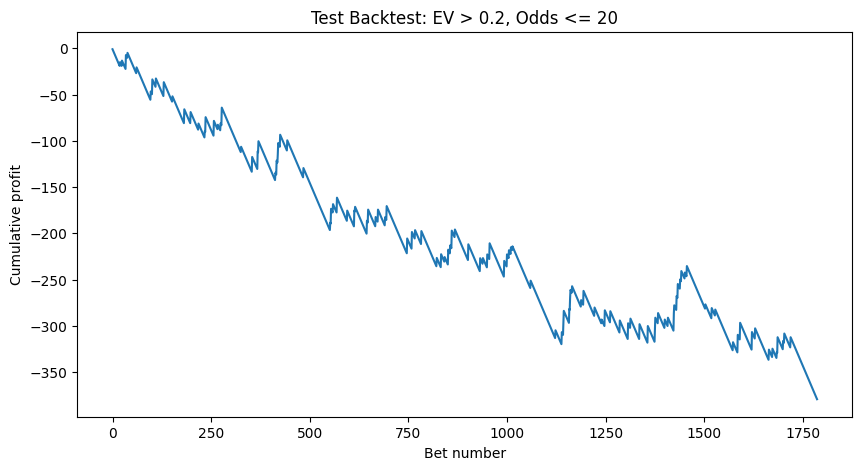

In [14]:
plot_cumulative_profit(
    test_bets,
    title=f"Test Backtest: EV > {best_threshold}, Odds <= 20",
)

In [15]:
display(test_bets[[
    "date",
    "race_id",
    "horse_id",
    "won",
    "win_odds",
    "model_prob",
    "market_prob",
    "expected_profit",
    "profit",
    "cumulative_profit",
]].head(30))

,date,race_id,horse_id,won,win_odds,model_prob,market_prob,expected_profit,profit,cumulative_profit
0,2003-12-23,5060,1495,0,13.0,0.214515,0.061935,1.788689,-1.0,-1.0
1,2003-12-23,5061,1722,0,11.0,0.115477,0.074139,0.270251,-1.0,-2.0
2,2003-12-23,5062,3433,0,18.0,0.071538,0.045192,0.287691,-1.0,-3.0
3,2003-12-23,5063,210,0,10.0,0.147514,0.081060,0.475137,-1.0,-4.0
4,2003-12-23,5064,2225,0,13.0,0.092378,0.061051,0.200920,-1.0,-5.0
5,2003-12-23,5064,632,0,15.0,0.129598,0.052911,0.943976,-1.0,-6.0
6,2003-12-23,5065,1296,0,11.0,0.162553,0.072707,0.788080,-1.0,-7.0
7,2003-12-23,5065,4327,0,11.0,0.150828,0.072707,0.659109,-1.0,-8.0
8,2003-12-23,5066,1565,0,9.4,0.169124,0.084238,0.589768,-1.0,-9.0
9,2003-12-23,5066,2217,0,12.0,0.144940,0.065986,0.739275,-1.0,-10.0


In [16]:
valid_calibration = calibration_table(valid_pred)
test_calibration = calibration_table(test_pred)

print("Validation calibration")
display(valid_calibration)

print("Test calibration")
display(test_calibration)

Validation calibration


,prob_bucket,avg_predicted_prob,actual_win_rate,count,calibration_error
0,"(0.0004599999999999999, 0.0182]",0.011239,0.008861,1580,-0.002378
1,"(0.0182, 0.0291]",0.023684,0.015833,1579,-0.007851
2,"(0.0291, 0.0401]",0.034448,0.028481,1580,-0.005967
3,"(0.0401, 0.0519]",0.045697,0.036099,1579,-0.009599
4,"(0.0519, 0.0652]",0.058385,0.048101,1580,-0.010283
5,"(0.0652, 0.08]",0.072211,0.064598,1579,-0.007613
6,"(0.08, 0.0989]",0.088976,0.108930,1579,0.019954
7,"(0.0989, 0.123]",0.110706,0.113924,1580,0.003218
8,"(0.123, 0.162]",0.141319,0.148195,1579,0.006876
9,"(0.162, 0.494]",0.214837,0.231646,1580,0.016809


Test calibration


,prob_bucket,avg_predicted_prob,actual_win_rate,count,calibration_error
0,"(0.00065, 0.0201]",0.011636,0.008050,1615,-0.003586
1,"(0.0201, 0.0324]",0.026417,0.021066,1614,-0.005351
2,"(0.0324, 0.0438]",0.038239,0.039033,1614,0.000794
3,"(0.0438, 0.0553]",0.049559,0.043990,1614,-0.005569
4,"(0.0553, 0.0674]",0.061301,0.044582,1615,-0.016719
5,"(0.0674, 0.0814]",0.074216,0.072491,1614,-0.001725
6,"(0.0814, 0.0985]",0.089689,0.093556,1614,0.003868
7,"(0.0985, 0.121]",0.108727,0.116481,1614,0.007753
8,"(0.121, 0.155]",0.136156,0.138786,1614,0.002630
9,"(0.155, 0.463]",0.201908,0.221053,1615,0.019145


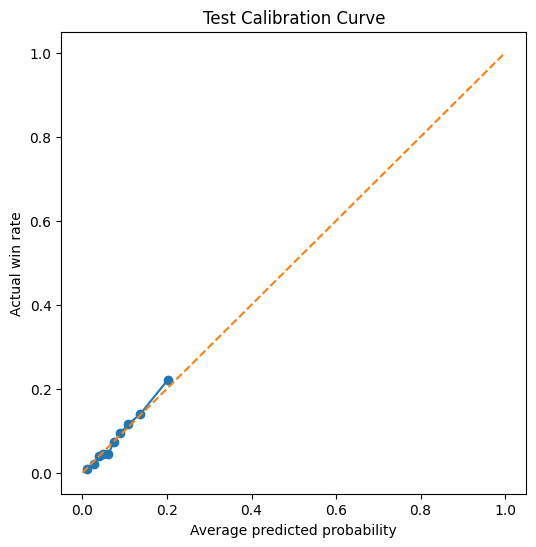

In [17]:
plot_calibration_curve(
    test_calibration,
    title="Test Calibration Curve",
)

In [18]:
top_predictions(test_pred, n=20)

,race_id,horse_id,won,win_odds,model_prob,market_prob,expected_profit
65834,5260,3639,1,1.6,0.462957,0.511193,-0.259269
66244,5293,1601,1,1.2,0.450496,0.673173,-0.459405
69078,5520,84,0,1.9,0.432347,0.425706,-0.178541
68791,5497,3332,0,5.4,0.417448,0.150999,1.254218
63523,5077,2525,0,1.4,0.397200,0.570136,-0.443920
66132,5284,1792,0,2.2,0.391756,0.370034,-0.138136
73107,5840,1124,1,1.6,0.383162,0.503030,-0.386941
64170,5128,305,0,2.8,0.381336,0.288364,0.067742
79314,6339,1352,0,1.3,0.367536,0.632836,-0.522203
68676,5489,1188,1,2.2,0.363084,0.366242,-0.201215


In [19]:
top_value_bets(test_pred, n=20)

,race_id,horse_id,won,win_odds,model_prob,market_prob,edge,expected_profit
66815,5338,430,0,99.0,0.147065,0.008235,0.138830,13.559391
76209,6089,3860,0,99.0,0.144179,0.008223,0.135956,13.273740
70853,5660,4108,0,99.0,0.143320,0.008083,0.135237,13.188702
68871,5503,3922,0,99.0,0.117947,0.008015,0.109932,10.676801
67685,5410,3434,0,99.0,0.117808,0.008315,0.109494,10.663020
69438,5549,2288,0,83.0,0.137096,0.009742,0.127354,10.378977
69336,5541,2608,0,99.0,0.109853,0.008186,0.101667,9.875468
67352,5384,1515,0,99.0,0.107676,0.008215,0.099461,9.659916
66773,5335,2108,0,99.0,0.104546,0.008182,0.096365,9.350101
76479,6111,1279,0,94.0,0.107524,0.008684,0.098840,9.107276


In [20]:
valid_pred.to_csv(OUTPUT_DIR / "valid_predictions.csv", index=False)
test_pred.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)
test_bets.to_csv(OUTPUT_DIR / "test_bets.csv", index=False)
valid_threshold_results.to_csv(OUTPUT_DIR / "valid_threshold_results.csv", index=False)
valid_calibration.to_csv(OUTPUT_DIR / "valid_calibration.csv", index=False)
test_calibration.to_csv(OUTPUT_DIR / "test_calibration.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: C:\Users\PzEdu\Documents\Projects\HK_Racing\outputs


In [ ]:
import joblib

joblib.dump(model, OUTPUT_DIR / "model.joblib")

SyntaxError: unterminated string literal (detected at line 3) (1727053834.py, line 3)